In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns


In [2]:
e=pd.read_csv("/content/youtube recommendation dataset.csv")

In [3]:
e.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 14 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   user_id            1000000 non-null  int64  
 1   video_id           1000000 non-null  int64  
 2   video_duration     1000000 non-null  int64  
 3   watch_time         1000000 non-null  float64
 4   liked              997952 non-null   object 
 5   commented          1000000 non-null  int64  
 6   subscribed_after   1000000 non-null  int64  
 7   category           1000000 non-null  object 
 8   device             1000000 non-null  object 
 9   watch_time_of_day  1000000 non-null  object 
 10  recommended        1000000 non-null  int64  
 11  clicked            1000000 non-null  int64  
 12  timestamp          1000000 non-null  object 
 13  watch_percent      1000000 non-null  float64
dtypes: float64(2), int64(7), object(5)
memory usage: 106.8+ MB


In [4]:
e.isnull().sum()

,0
user_id,0
video_id,0
video_duration,0
watch_time,0
liked,2048
commented,0
subscribed_after,0
category,0
device,0
watch_time_of_day,0


In [5]:
e[["recommended","clicked","timestamp","watch_percent"]] = (e[["recommended","clicked","timestamp","watch_percent"]].fillna(e[["recommended","clicked","timestamp","watch_percent"]].mode()))

In [6]:
e.isnull().sum()

,0
user_id,0
video_id,0
video_duration,0
watch_time,0
liked,2048
commented,0
subscribed_after,0
category,0
device,0
watch_time_of_day,0


In [7]:
e["liked"]=e["liked"].fillna(e["liked"].mode)

In [8]:
e.isnull().sum()

,0
user_id,0
video_id,0
video_duration,0
watch_time,0
liked,0
commented,0
subscribed_after,0
category,0
device,0
watch_time_of_day,0


In [9]:
e.describe(include="all")

,user_id,video_id,video_duration,watch_time,liked,commented,subscribed_after,category,device,watch_time_of_day,recommended,clicked,timestamp,watch_percent
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000,1000000.000000,1000000.000000,1000000,1000000,1000000,1000000.000000,1000000.000000,1000000,1.000000e+06
unique,NaN,NaN,NaN,NaN,6,NaN,NaN,14,4,4,NaN,NaN,994335,NaN
top,NaN,NaN,NaN,NaN,0,NaN,NaN,Comedy,TV,Morning,NaN,NaN,2023-10-16 02:39:19,NaN
freq,NaN,NaN,NaN,NaN,696155,NaN,NaN,124467,250083,250258,NaN,NaN,3,NaN
mean,50014.595087,25008.932584,1911.577131,1283.683469,NaN,0.099497,0.050004,NaN,NaN,NaN,0.399768,0.300771,NaN,inf
std,28864.277887,14434.546717,3270.284893,2499.074293,NaN,0.299328,0.217953,NaN,NaN,NaN,0.489851,0.458594,NaN,NaN
min,1.000000,1.000000,0.000000,-299.000000,NaN,0.000000,0.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,-2.990000e-03
25%,24998.000000,12503.000000,921.000000,498.000000,NaN,0.000000,0.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,4.990537e-01
50%,50048.000000,25020.000000,1816.000000,1071.000000,NaN,0.000000,0.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,9.963570e-01
75%,75022.000000,37522.000000,2710.000000,1821.000000,NaN,0.000000,0.000000,NaN,NaN,NaN,1.000000,1.000000,NaN,1.000000e+00


In [10]:
e.shape

(1000000, 14)

In [11]:
e.columns

Index(['user_id', 'video_id', 'video_duration', 'watch_time', 'liked',
       'commented', 'subscribed_after', 'category', 'device',
       'watch_time_of_day', 'recommended', 'clicked', 'timestamp',
       'watch_percent'],
      dtype='object')

In [12]:
e.columns.str.strip()

Index(['user_id', 'video_id', 'video_duration', 'watch_time', 'liked',
       'commented', 'subscribed_after', 'category', 'device',
       'watch_time_of_day', 'recommended', 'clicked', 'timestamp',
       'watch_percent'],
      dtype='object')

In [13]:
e.select_dtypes(include="object")

,liked,category,device,watch_time_of_day,timestamp
0,1,News,TV,Night,2025-07-16 06:10:54
1,1,Education,Mobile,Night,2024-07-09 10:22:22
2,0,Sports,Desktop,Afternoon,2025-02-07 09:46:36
3,1,Gaming,TV,Evening,2024-04-28 08:07:13
4,0,Lifestyle,Desktop,Evening,2024-03-30 12:54:24
...,...,...,...,...,...
999995,0,Sports,Tablet,Morning,2024-01-09 16:41:36
999996,1,Education,TV,Evening,2024-03-14 22:22:54
999997,1,Tech,Tablet,Evening,2023-09-06 08:54:24
999998,0,News,Mobile,Night,2025-03-28 01:31:39


In [14]:
e.select_dtypes(include="object").columns

Index(['liked', 'category', 'device', 'watch_time_of_day', 'timestamp'], dtype='object')

In [15]:
e.select_dtypes(include="float64")

,watch_time,watch_percent
0,1499.0,1.000000
1,2955.0,1.000000
2,389.0,1.000000
3,1231.0,1.000000
4,353.0,0.098797
...,...,...
999995,1902.0,0.795816
999996,311.0,1.000000
999997,2472.0,1.000000
999998,1725.0,1.000000


In [16]:
e.select_dtypes(include="float64").columns

Index(['watch_time', 'watch_percent'], dtype='object')

In [17]:
e.describe(include="object")

,liked,category,device,watch_time_of_day,timestamp
count,1000000,1000000,1000000,1000000,1000000
unique,6,14,4,4,994335
top,0,Comedy,TV,Morning,2023-10-16 02:39:19
freq,696155,124467,250083,250258,3


In [18]:
e.dtypes

,0
user_id,int64
video_id,int64
video_duration,int64
watch_time,float64
liked,object
commented,int64
subscribed_after,int64
category,object
device,object
watch_time_of_day,object


In [19]:
e[["watch_time","watch_percent"]]

,watch_time,watch_percent
0,1499.0,1.000000
1,2955.0,1.000000
2,389.0,1.000000
3,1231.0,1.000000
4,353.0,0.098797
...,...,...
999995,1902.0,0.795816
999996,311.0,1.000000
999997,2472.0,1.000000
999998,1725.0,1.000000


In [20]:
e.loc[:,["category","device"]]

,category,device
0,News,TV
1,Education,Mobile
2,Sports,Desktop
3,Gaming,TV
4,Lifestyle,Desktop
...,...,...
999995,Sports,Tablet
999996,Education,TV
999997,Tech,Tablet
999998,News,Mobile


In [21]:
e.select_dtypes(include="number").columns

Index(['user_id', 'video_id', 'video_duration', 'watch_time', 'commented',
       'subscribed_after', 'recommended', 'clicked', 'watch_percent'],
      dtype='object')

In [22]:
e.select_dtypes(include="object").columns

Index(['liked', 'category', 'device', 'watch_time_of_day', 'timestamp'], dtype='object')

In [23]:
e["category"].unique()

array(['News', 'Education', 'Sports', 'Gaming', 'Lifestyle', 'Music',
       'Tech', 'Comedy', 'MUsic', 'gamingg', 'music', 'Ed', 'COMEDY',
       'Tech '], dtype=object)

In [24]:
e["device"].nunique()

4

In [25]:
e["category"].value_counts(normalize=True)

,proportion
category,
Comedy,0.124467
News,0.123920
Music,0.123851
Tech,0.123735
Sports,0.123644
Gaming,0.123595
Lifestyle,0.123457
Education,0.123331
Tech,0.001749


In [26]:
e.sort_values("watch_time")

,user_id,video_id,video_duration,watch_time,liked,commented,subscribed_after,category,device,watch_time_of_day,recommended,clicked,timestamp,watch_percent
149829,43348,40834,100000,-299.0,2,0,0,gamingg,Desktop,Morning,0,0,1700851517,-0.00299
957861,88147,35429,100000,-298.0,no,0,0,MUsic,Tablet,Morning,0,0,1720840012,-0.00298
463859,75797,9718,100000,-298.0,yes,0,0,gamingg,Desktop,Afternoon,1,0,1707037681,-0.00298
132637,8012,611,100000,-298.0,<bound method Series.mode of 0 1\n1 ...,0,0,Tech,Tablet,Morning,1,0,1749175114,-0.00298
466782,64632,40291,100000,-297.0,yes,0,0,Ed,Tablet,Morning,0,0,1673641376,-0.00297
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795862,16973,2900,100000,109879.0,<bound method Series.mode of 0 1\n1 ...,0,1,music,Tablet,Morning,0,1,1718734740,1.09879
811445,64403,41085,100000,109950.0,<bound method Series.mode of 0 1\n1 ...,0,0,music,TV,Night,0,1,1688988438,1.09950
924326,80900,9105,100000,109950.0,yes,0,0,Tech,Mobile,Night,0,0,1716042071,1.09950
343250,50004,12600,100000,109951.0,yes,0,0,COMEDY,Tablet,Afternoon,1,0,1737791382,1.09951


In [27]:
e.sort_values("watch_time",ascending=False)

,user_id,video_id,video_duration,watch_time,liked,commented,subscribed_after,category,device,watch_time_of_day,recommended,clicked,timestamp,watch_percent
771016,42408,3296,100000,109969.0,2,0,0,gamingg,TV,Afternoon,0,0,1729771764,1.09969
343250,50004,12600,100000,109951.0,yes,0,0,COMEDY,Tablet,Afternoon,1,0,1737791382,1.09951
924326,80900,9105,100000,109950.0,yes,0,0,Tech,Mobile,Night,0,0,1716042071,1.09950
811445,64403,41085,100000,109950.0,<bound method Series.mode of 0 1\n1 ...,0,0,music,TV,Night,0,1,1688988438,1.09950
795862,16973,2900,100000,109879.0,<bound method Series.mode of 0 1\n1 ...,0,1,music,Tablet,Morning,0,1,1718734740,1.09879
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
466782,64632,40291,100000,-297.0,yes,0,0,Ed,Tablet,Morning,0,0,1673641376,-0.00297
132637,8012,611,100000,-298.0,<bound method Series.mode of 0 1\n1 ...,0,0,Tech,Tablet,Morning,1,0,1749175114,-0.00298
957861,88147,35429,100000,-298.0,no,0,0,MUsic,Tablet,Morning,0,0,1720840012,-0.00298
463859,75797,9718,100000,-298.0,yes,0,0,gamingg,Desktop,Afternoon,1,0,1707037681,-0.00298


In [28]:
e[e["watch_percent"]>80]

,user_id,video_id,video_duration,watch_time,liked,commented,subscribed_after,category,device,watch_time_of_day,recommended,clicked,timestamp,watch_percent
177,25238,4381,0,1213.0,no,0,0,MUsic,Desktop,Afternoon,1,0,1744178555,inf
241,73786,2261,0,943.0,no,0,0,MUsic,Desktop,Night,0,0,1683190037,inf
641,80857,41009,0,5549.0,yes,0,0,music,Mobile,Night,0,0,1708636577,inf
1444,14426,13154,0,6633.0,<bound method Series.mode of 0 1\n1 ...,0,0,COMEDY,Tablet,Evening,1,1,1711575217,inf
3084,7060,10372,0,1392.0,no,0,0,MUsic,Tablet,Evening,1,0,1681036320,inf
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996369,7234,6224,0,6442.0,<bound method Series.mode of 0 1\n1 ...,0,0,Tech,Desktop,Morning,0,0,1691121794,inf
996593,10247,32332,0,9639.0,yes,1,0,gamingg,Tablet,Night,1,0,1758993566,inf
997409,33684,48262,0,7380.0,no,0,0,gamingg,Mobile,Evening,1,1,1679693796,inf
998246,12985,30246,0,9012.0,2,0,0,MUsic,Mobile,Evening,1,0,1678056904,inf


In [29]:
e.groupby("category")["watch_time"].mean()

,watch_time
category,
COMEDY,8440.998111
Comedy,1212.419453
Ed,9117.282834
Education,1215.305098
Gaming,1210.344067
Lifestyle,1213.576881
MUsic,8494.821407
Music,1210.519527
News,1207.534611


In [30]:
e.groupby(["category","device"]).agg(avg_percent=("watch_percent","mean"))

avg_percent
category  device              
COMEDY    Desktop          inf
          Mobile           inf
          TV               inf
          Tablet           inf
Comedy    Desktop     0.749616
          Mobile      0.753637
          TV          0.747705
          Tablet      0.746980
Ed        Desktop          inf
          Mobile           inf
          TV               inf
          Tablet           inf
Education Desktop     0.748973
          Mobile      0.749001
          TV          0.751217
          Tablet      0.747208
Gaming    Desktop     0.747542
          Mobile      0.748683
          TV          0.749128
          Tablet      0.748913
Lifestyle Desktop     0.749107
          Mobile      0.748455
          TV          0.749301
          Tablet      0.751981
MUsic     Desktop          inf
          Mobile           inf
          TV               inf
          Tablet           inf
Music     Desktop     0.749191
          Mobile      0.745580
          TV          0.749719
          Tablet      0.750507
News      Desktop     0.745940
          Mobile      0.748136
          TV          0.748177
          Tablet      0.747542
Sports    Desktop     0.748422
          Mobile      0.748809
          TV          0.746400
          Tablet      0.751586
Tech      Desktop     0.750958
          Mobile      0.745844
          TV          0.746646
          Tablet      0.749586
Tech      Desktop          inf
          Mobile           inf
          TV               inf
          Tablet           inf
gamingg   Desktop          inf
          Mobile           inf
          TV               inf
          Tablet           inf
music     Desktop          inf
          Mobile           inf
          TV               inf
          Tablet           inf

In [31]:
e.groupby("category").describe()

user_id                                                       \
              count          mean           std   min       25%      50%   
category                                                                   
COMEDY       1588.0  49556.930730  29030.385103   1.0  24844.75  49553.0   
Comedy     124467.0  50071.271100  28865.718045   2.0  25080.50  50044.0   
Ed           1637.0  50157.930360  29003.841012  22.0  24674.00  51057.0   
Education  123331.0  49965.784904  28866.328383   2.0  25000.50  49985.0   
Gaming     123595.0  50024.265035  28865.020942   1.0  24970.50  50101.0   
Lifestyle  123457.0  49937.201155  28877.519245   1.0  24857.00  49890.0   
MUsic        1663.0  49012.430547  28546.126381   3.0  24271.00  47582.0   
Music      123851.0  50047.610952  28812.954081   2.0  25050.50  50204.0   
News       123920.0  50015.185886  28894.865936   1.0  24995.00  50106.0   
Sports     123644.0  49968.676005  28873.769991   1.0  24896.75  49958.0   
Tech       123735.0  50099.948083  28861.581881   2.0  25156.50  50096.0   
Tech         1749.0  49994.851344  28573.085752   6.0  25599.00  49841.0   
gamingg      1734.0  50155.785467  28910.697258  16.0  25035.50  49963.0   
music        1629.0  50154.451197  28938.644841  38.0  25277.00  50095.0   

                               video_id                ... clicked       \
                75%       max     count          mean  ...     75%  max   
category                                               ...                
COMEDY     74642.50   99966.0    1588.0  24900.003149  ...     1.0  1.0   
Comedy     75084.00   99999.0  124467.0  25045.642122  ...     1.0  1.0   
Ed         74631.00   99825.0    1637.0  24261.094075  ...     1.0  1.0   
Education  75019.00  100000.0  123331.0  24994.847265  ...     1.0  1.0   
Gaming     74997.50  100000.0  123595.0  25018.151924  ...     1.0  1.0   
Lifestyle  74954.00  100000.0  123457.0  24981.188535  ...     1.0  1.0   
MUsic      74025.50   99986.0    1663.0  24882.833434  ...     1.0  1.0   
Music      74934.00   99999.0  123851.0  25079.189090  ...     1.0  1.0   
News       74953.25  100000.0  123920.0  24973.871361  ...     1.0  1.0   
Sports     75015.25  100000.0  123644.0  25006.638130  ...     1.0  1.0   
Tech       75260.00  100000.0  123735.0  24987.650689  ...     1.0  1.0   
Tech       74101.00   99973.0    1749.0  25173.944540  ...     1.0  1.0   
gamingg    75550.25   99981.0    1734.0  24794.131488  ...     1.0  1.0   
music      75763.00   99968.0    1629.0  24827.825046  ...     1.0  1.0   

          watch_percent                                                    \
                  count      mean       std       min       25%       50%   
category                                                                    
COMEDY           1588.0       inf       NaN -0.002890  0.773212  1.000000   
Comedy         124467.0  0.749485  0.321864  0.001455  0.500000  0.993746   
Ed               1637.0       inf       NaN -0.002970  0.821826  1.000000   
Education      123331.0  0.749103  0.322249  0.001419  0.497933  0.991407   
Gaming         123595.0  0.748569  0.322142  0.001460  0.496070  0.991884   
Lifestyle      123457.0  0.749717  0.321350  0.001405  0.500377  0.993821   
MUsic            1663.0       inf       NaN -0.002980  0.824931  1.000000   
Music          123851.0  0.748751  0.322839  0.001431  0.497089  0.994403   
News           123920.0  0.747442  0.323003  0.001406  0.494078  0.988786   
Sports         123644.0  0.748801  0.322256  0.001457  0.498054  0.993354   
Tech           123735.0  0.748259  0.322251  0.001403  0.495582  0.991925   
Tech             1749.0       inf       NaN -0.002980  0.858124  1.000000   
gamingg          1734.0       inf       NaN -0.002990  0.775760  1.000000   
music            1629.0       inf       NaN -0.002960  0.864072  1.000000   

                          
                75%  max  
category                  
COMEDY     3.658843  inf  
Comedy     1.000000  1.0 

In [32]:
e["liked"].replace({"Yes":1,"No":0})

,liked
0,1
1,1
2,0
3,1
4,0
...,...
999995,0
999996,1
999997,1
999998,0


<Axes: xlabel='category'>

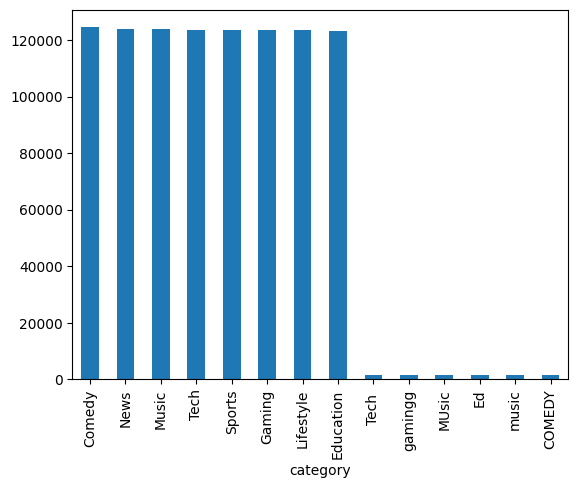

In [35]:
e["category"].value_counts().plot(kind="bar")

<Axes: xlabel='device'>

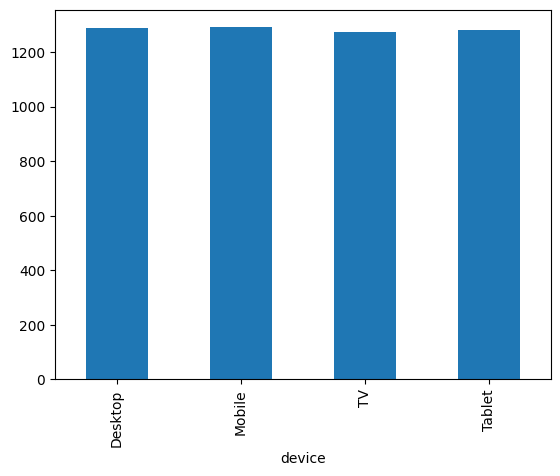

In [39]:
e.groupby("device")["watch_time"].mean().plot(kind="bar")

In [40]:
e.sample(10000)

,user_id,video_id,video_duration,watch_time,liked,commented,subscribed_after,category,device,watch_time_of_day,recommended,clicked,timestamp,watch_percent
766284,45088,36634,3071,1119.0,1,1,0,Comedy,Tablet,Morning,1,1,2023-05-06 23:47:07,0.364376
26749,43904,22936,1853,1853.0,0,0,0,Gaming,Tablet,Afternoon,0,0,2024-10-19 10:11:18,1.000000
81050,6718,14491,1596,1596.0,0,0,0,Education,TV,Afternoon,0,0,2025-08-19 09:30:00,1.000000
574317,96656,35941,1185,1185.0,1,0,0,Sports,Tablet,Afternoon,1,0,2023-07-13 00:22:53,1.000000
346212,92109,7162,3362,704.0,0,0,0,Music,Desktop,Night,0,0,2023-06-27 03:34:13,0.209399
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
683861,15540,46164,1150,822.0,1,0,0,News,Tablet,Morning,0,0,2023-12-15 15:13:26,0.714783
916461,28681,22196,2341,2341.0,0,0,0,Comedy,Mobile,Night,0,1,2023-06-24 13:05:34,1.000000
687600,51566,45791,389,111.0,0,0,0,Sports,Desktop,Morning,1,0,2023-08-30 03:03:46,0.285347
501244,34140,34302,585,585.0,0,0,0,Gaming,Desktop,Night,0,0,2024-06-26 10:05:51,1.000000


In [41]:
e.rename(columns={"liked":"is_liked"})

,user_id,video_id,video_duration,watch_time,is_liked,commented,subscribed_after,category,device,watch_time_of_day,recommended,clicked,timestamp,watch_percent
0,88263,19387,1499,1499.0,1,0,0,News,TV,Night,0,0,2025-07-16 06:10:54,1.000000
1,46796,5150,2955,2955.0,1,0,0,Education,Mobile,Night,1,1,2024-07-09 10:22:22,1.000000
2,77686,3172,389,389.0,0,0,0,Sports,Desktop,Afternoon,0,0,2025-02-07 09:46:36,1.000000
3,26723,27669,1231,1231.0,1,1,0,Gaming,TV,Evening,0,0,2024-04-28 08:07:13,1.000000
4,55299,24612,3573,353.0,0,1,0,Lifestyle,Desktop,Evening,1,0,2024-03-30 12:54:24,0.098797
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,30850,24888,2390,1902.0,0,0,0,Sports,Tablet,Morning,0,0,2024-01-09 16:41:36,0.795816
999996,14324,3681,311,311.0,1,0,0,Education,TV,Evening,0,0,2024-03-14 22:22:54,1.000000
999997,963,11107,2472,2472.0,1,0,0,Tech,Tablet,Evening,0,0,2023-09-06 08:54:24,1.000000
999998,87484,40134,1725,1725.0,0,0,1,News,Mobile,Night,1,0,2025-03-28 01:31:39,1.000000


In [43]:
e.duplicated().value_counts()

,count
False,1000000


In [44]:
e.duplicated().sum()

np.int64(0)

In [45]:
e[e.duplicated()]

,user_id,video_id,video_duration,watch_time,liked,commented,subscribed_after,category,device,watch_time_of_day,recommended,clicked,timestamp,watch_percent


In [46]:
e.index

RangeIndex(start=0, stop=1000000, step=1)

In [47]:
e["device"].str.upper()

,device
0,TV
1,MOBILE
2,DESKTOP
3,TV
4,DESKTOP
...,...
999995,TABLET
999996,TV
999997,TABLET
999998,MOBILE


In [49]:
e["category"].str.startswith("A").sum()

np.int64(0)

In [50]:
e["category"].str.len()

,category
0,4
1,9
2,6
3,6
4,9
...,...
999995,6
999996,9
999997,4
999998,4


In [53]:
e["watch_rank"] = e["watch_time"].rank()
e["watch_rank"]

,watch_rank
0,653346.5
1,963945.5
2,196467.5
3,560423.5
4,178401.5
...,...
999995,772224.0
999996,157054.0
999997,897412.5
999998,722985.0


In [54]:
e["watch_rank"].unique()

array([653346.5, 963945.5, 196467.5, ..., 999033. , 997668. , 996766. ])

In [56]:
pd.crosstab(e["device"],e["liked"])

liked,"<bound method Series.mode of 0 1\n1 1\n2 0\n3 1\n4 0\n ..\n999995 0\n999996 1\n999997 1\n999998 0\n999999 0\nName: liked, Length: 1000000, dtype: object>",0,1,2,no,yes
device,,,,,,
Desktop,502,174088,74624,247,279,243
Mobile,533,173821,74779,252,256,227
TV,499,173979,74874,256,218,257
Tablet,514,174267,74568,252,235,230


In [60]:
e.query("watch_percent > 99")

,user_id,video_id,video_duration,watch_time,liked,commented,subscribed_after,category,device,watch_time_of_day,recommended,clicked,timestamp,watch_percent,watch_rank
177,25238,4381,0,1213.0,no,0,0,MUsic,Desktop,Afternoon,1,0,1744178555,inf,553837.0
241,73786,2261,0,943.0,no,0,0,MUsic,Desktop,Night,0,0,1683190037,inf,448152.5
641,80857,41009,0,5549.0,yes,0,0,music,Mobile,Night,0,0,1708636577,inf,997178.5
1444,14426,13154,0,6633.0,<bound method Series.mode of 0 1\n1 ...,0,0,COMEDY,Tablet,Evening,1,1,1711575217,inf,997564.0
3084,7060,10372,0,1392.0,no,0,0,MUsic,Tablet,Evening,1,0,1681036320,inf,617646.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996369,7234,6224,0,6442.0,<bound method Series.mode of 0 1\n1 ...,0,0,Tech,Desktop,Morning,0,0,1691121794,inf,997500.0
996593,10247,32332,0,9639.0,yes,1,0,gamingg,Tablet,Night,1,0,1758993566,inf,998770.0
997409,33684,48262,0,7380.0,no,0,0,gamingg,Mobile,Evening,1,1,1679693796,inf,997874.0
998246,12985,30246,0,9012.0,2,0,0,MUsic,Mobile,Evening,1,0,1678056904,inf,998545.0


In [61]:
e.sample(random_state=42)

,user_id,video_id,video_duration,watch_time,liked,commented,subscribed_after,category,device,watch_time_of_day,recommended,clicked,timestamp,watch_percent,watch_rank
987231,83761,40026,2416,2416.0,0,0,0,Lifestyle,Tablet,Night,0,0,2024-05-18 15:10:21,1.0,887400.5
